<a href="https://colab.research.google.com/github/ayatayoub20/Time-Series-Analysis/blob/main/Preparing_Time_Series_from_Wide_Form_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Load and Prepare the Time Series Data

In this section, I loaded the Zillow Home Value Index dataset, filtered the four largest cities using `SizeRank`, converted the wide-form date columns into long-form using `pd.melt()`, converted the date column to datetime, set it as the index, and resampled the data by city using monthly frequency.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticks

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQN3Ksa9szQuO4G1-msXWAp17KtVHQCBnuEieu_auu1wSiBf3-krHusIx5VBMkihxj-KZLBosDIGEyR/pub?output=csv"

df = pd.read_csv(url)

df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,114794.0,114975.0,...,269323.0,274032.0,278464.0,284127.0,289739.0,294776.0,297727.0,298796.0,299124.0,298951.0


In [7]:
df4 = df[df['SizeRank'].isin([0,1,2,3])].copy()

df4[['RegionName','SizeRank']]

,RegionName,SizeRank
0,New York,0
1,Los Angeles,1
2,Houston,2
3,Chicago,3


In [8]:
id_vars = [
    'RegionID',
    'SizeRank',
    'RegionName',
    'RegionType',
    'StateName',
    'State',
    'Metro',
    'CountyName'
]

melted = pd.melt(
    df4,
    id_vars=id_vars,
    var_name='Date',
    value_name='HomeValue'
)

In [9]:
melted['Date'] = pd.to_datetime(melted['Date'])

melted = melted.set_index('Date')

melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,HomeValue
Date,,,,,,,,,
2000-01-31,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0
2000-01-31,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0
2000-01-31,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0
2000-01-31,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0
2000-02-29,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,255517.0


In [11]:
df_ts = melted.groupby('RegionName').resample('MS').mean(numeric_only=True)

df_ts.head()

RegionID  SizeRank  HomeValue
RegionName Date                                     
Chicago    2000-01-01   17426.0       3.0   166139.0
           2000-02-01   17426.0       3.0   166536.0
           2000-03-01   17426.0       3.0   167368.0
           2000-04-01   17426.0       3.0   168826.0
           2000-05-01   17426.0       3.0   170499.0

In [12]:
plot_df = df_ts['HomeValue'].unstack(level=0)

plot_df.head()

RegionName,Chicago,Houston,Los Angeles,New York
Date,,,,
2000-01-01,166139.0,109068.0,234181.0,253690.0
2000-02-01,166536.0,109079.0,234401.0,255517.0
2000-03-01,167368.0,108878.0,235513.0,257207.0
2000-04-01,168826.0,108881.0,237589.0,260310.0
2000-05-01,170499.0,108834.0,240113.0,263204.0


# Part 2: Visualizing Home Values for the Four Largest Cities

The following plot shows the typical home values over time for the four largest cities. The y-axis was formatted in thousands of dollars using `FuncFormatter` to improve readability.

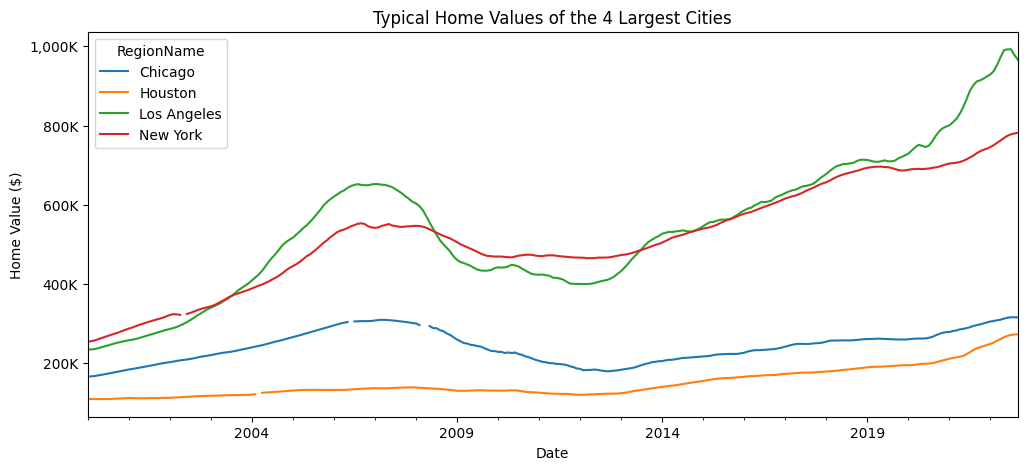

In [16]:
fig, ax = plt.subplots(figsize=(12,5))

plot_df.plot(ax=ax)

ax.set_title('Typical Home Values of the 4 Largest Cities')
ax.set_ylabel('Home Value ($)')
ax.set_xlabel('Date')

def thousands(x, pos):
    return f'{x/1000:,.0f}K'

fmt = mticks.FuncFormatter(thousands)
ax.yaxis.set_major_formatter(fmt)

plt.show()

# Question 1

Which city had the highest typical home value at the end of 2008? Which city had the lowest?

In [18]:
values_2008 = plot_df.loc['2008-12-01']

highest_city = values_2008.idxmax()
highest_value = values_2008.max()

lowest_city = values_2008.idxmin()
lowest_value = values_2008.min()

print(f"Highest city at the end of 2008: {highest_city} (${highest_value:,.0f})")
print(f"Lowest city at the end of 2008: {lowest_city} (${lowest_value:,.0f})")

Highest city at the end of 2008: New York ($510,309)
Lowest city at the end of 2008: Houston ($131,283)


### Answer

At the end of 2008, **New York** had the highest typical home value at **$510,309**.

**Houston** had the lowest typical home value at **$131,283**.

# Question 2

How much did the home values change from November 2008 to December 2008 in dollars?

In [19]:
monthly_change = plot_df.diff()

nov_dec_change = monthly_change.loc['2008-12-01']

for city, value in nov_dec_change.items():
    print(f"{city}: ${value:,.0f}")

Chicago: $-5,753
Houston: $-964
Los Angeles: $-12,611
New York: $-4,458


### Answer

The change in home values from November 2008 to December 2008 was:

- Chicago: **-$5,753**
- Houston: **-$964**
- Los Angeles: **-$12,611**
- New York: **-$4,458**

All four cities experienced a decrease in home values during this period, with **Los Angeles** showing the largest decline.